In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib import colors

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

def show(img, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

def show_pair(a, b, title1="Input", title2="Result"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    show(a, title1, axes[0])
    show(b, title2, axes[1])
    plt.tight_layout()

def show_triplet(a, b, c, t1="A", t2="B", t3="C"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    show(a, t1, axes[0])
    show(b, t2, axes[1])
    show(c, t3, axes[2])
    plt.tight_layout()

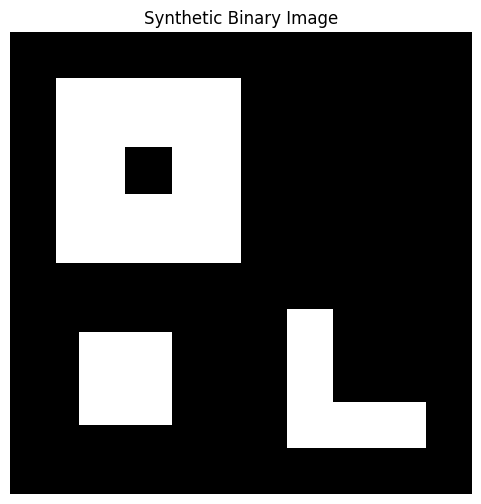

In [4]:

img = np.zeros((20, 20), dtype=np.uint8)

img[2:10, 2:10] = 1

img[5:7, 5:7] = 0

img[13:17, 3:7] = 1

img[12:18, 12:14] = 1
img[16:18, 12:18] = 1

show(img, "Synthetic Binary Image")
plt.show()

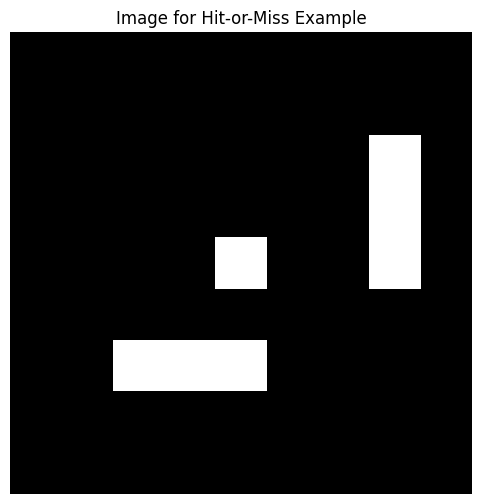

In [5]:
hm_img = np.zeros((9, 9), dtype=np.uint8)
hm_img[4, 4] = 1
hm_img[2:5, 7] = 1
hm_img[6, 2:5] = 1

show(hm_img, "Image for Hit-or-Miss Example")
plt.show()

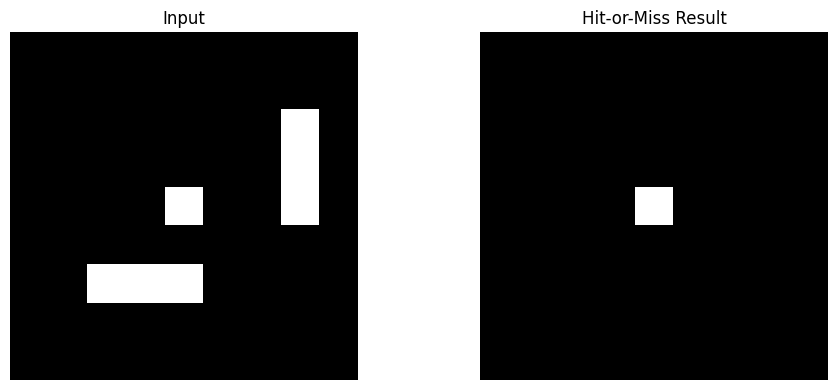

In [6]:
B1 = np.array([[0,0,0],
               [0,1,0],
               [0,0,0]], dtype=bool)

B2 = np.array([[1,1,1],
               [1,0,1],
               [1,1,1]], dtype=bool)

foreground_match = ndimage.binary_erosion(hm_img, structure=B1)
background_match = ndimage.binary_erosion(1 - hm_img, structure=B2)
hitmiss = foreground_match & background_match

show_pair(hm_img, hitmiss.astype(np.uint8), "Input", "Hit-or-Miss Result")
plt.show()

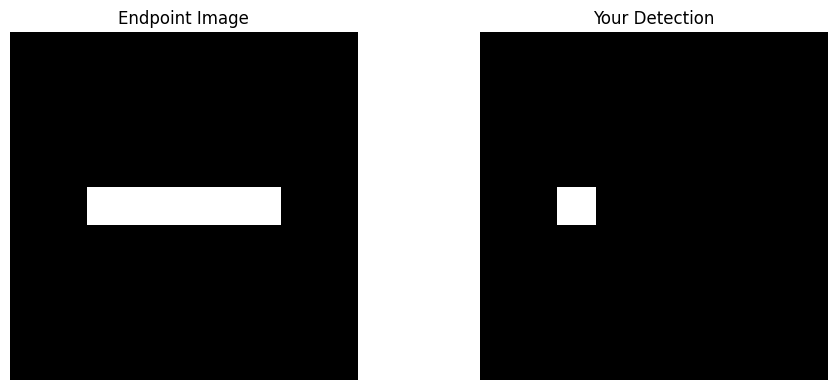

In [8]:
endpoint_img = np.zeros((9, 9), dtype=np.uint8)
endpoint_img[4, 2:7] = 1

B1_student = np.array([[0,0,0],
                       [0,1,1],
                       [0,0,0]], dtype=bool)

B2_student = np.array([[1,1,1],
                       [1,0,0],
                       [1,1,1]], dtype=bool)

fg = ndimage.binary_erosion(endpoint_img, structure=B1_student)
bg = ndimage.binary_erosion(1 - endpoint_img, structure=B2_student)
result_student = fg & bg

show_pair(endpoint_img, result_student.astype(np.uint8), "Endpoint Image", "Your Detection")
plt.show()

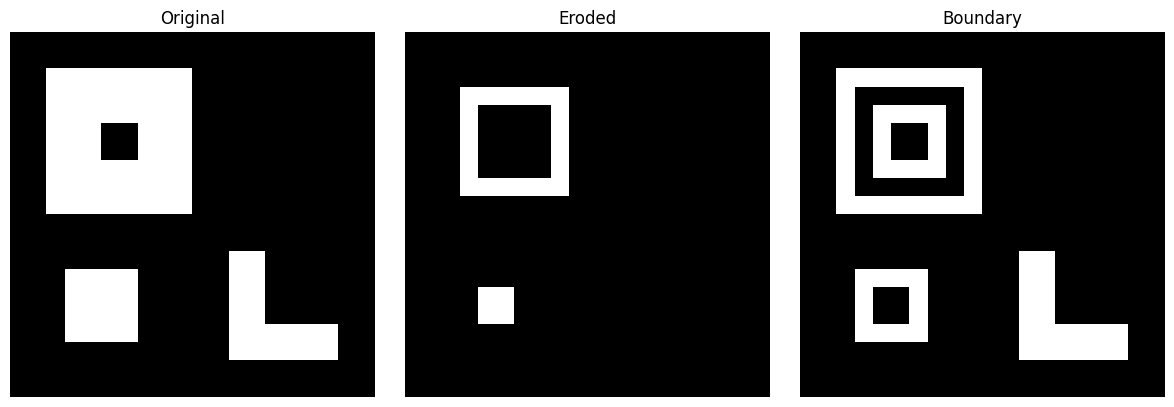

In [9]:
se = np.ones((3, 3), dtype=bool)
eroded = ndimage.binary_erosion(img, structure=se)
boundary = img & (~eroded)

show_triplet(img, eroded.astype(np.uint8), boundary.astype(np.uint8),
             "Original", "Eroded", "Boundary")
plt.show()

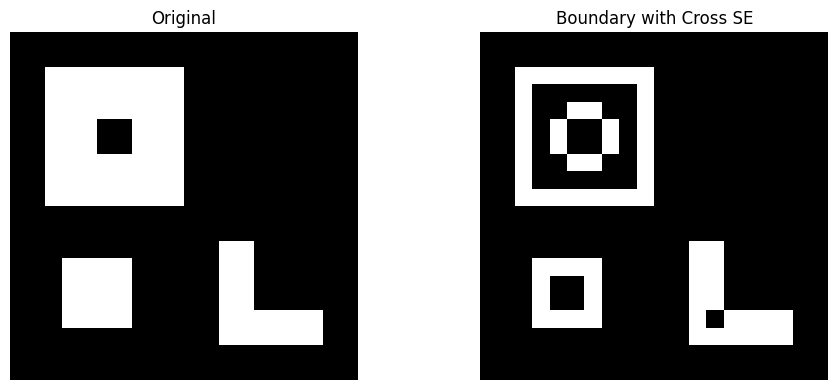

In [10]:
cross = np.array([[0,1,0],
                  [1,1,1],
                  [0,1,0]], dtype=bool)

eroded_cross = ndimage.binary_erosion(img, structure=cross)
boundary_cross = img & (~eroded_cross)

show_pair(img, boundary_cross.astype(np.uint8), "Original", "Boundary with Cross SE")
plt.show()

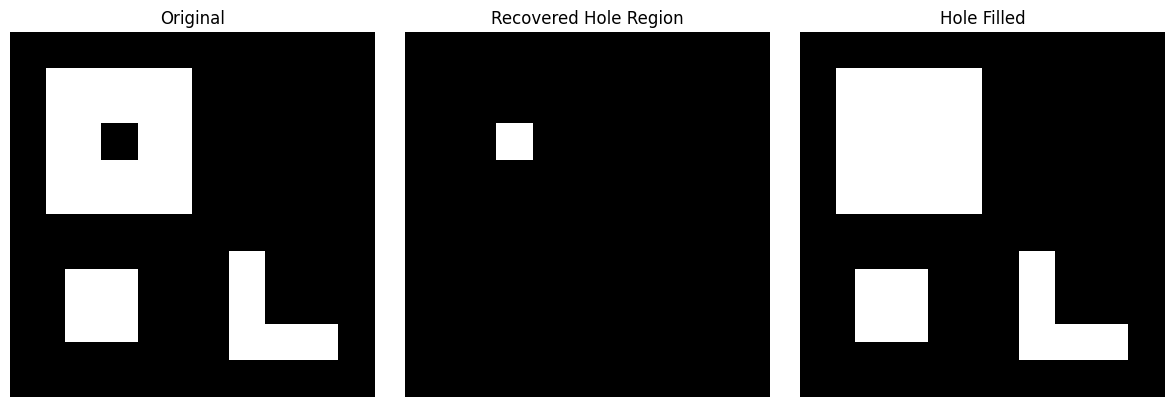

In [11]:
seed = np.zeros_like(img, dtype=bool)
seed[5, 5] = True

background = ~img.astype(bool)
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]], dtype=bool)

X_prev = seed.copy()

while True:
    X_next = ndimage.binary_dilation(X_prev, structure=structure) & background
    if np.array_equal(X_next, X_prev):
        break
    X_prev = X_next

filled_hole_region = X_prev
filled_img = img.astype(bool) | filled_hole_region

show_triplet(img, filled_hole_region.astype(np.uint8), filled_img.astype(np.uint8),
             "Original", "Recovered Hole Region", "Hole Filled")
plt.show()

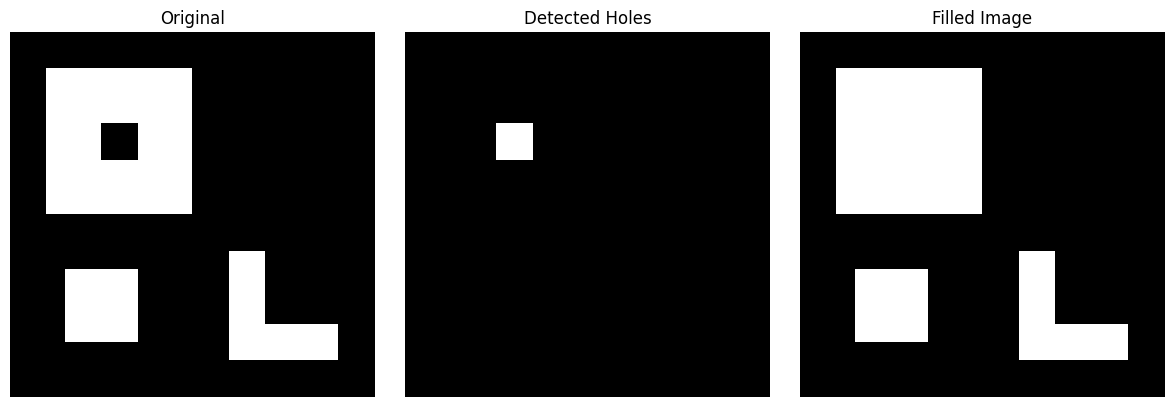

In [12]:
inv = 1 - img
seed_border = np.zeros_like(inv, dtype=bool)

seed_border[0, :] = inv[0, :]
seed_border[-1, :] = inv[-1, :]
seed_border[:, 0] = inv[:, 0]
seed_border[:, -1] = inv[:, -1]

outside = seed_border.copy()
while True:
    grown = ndimage.binary_dilation(outside, structure=structure) & inv.astype(bool)
    if np.array_equal(grown, outside):
        break
    outside = grown

holes = inv.astype(bool) & (~outside)
filled_by_border = img.astype(bool) | holes

show_triplet(img, holes.astype(np.uint8), filled_by_border.astype(np.uint8),
             "Original", "Detected Holes", "Filled Image")
plt.show()

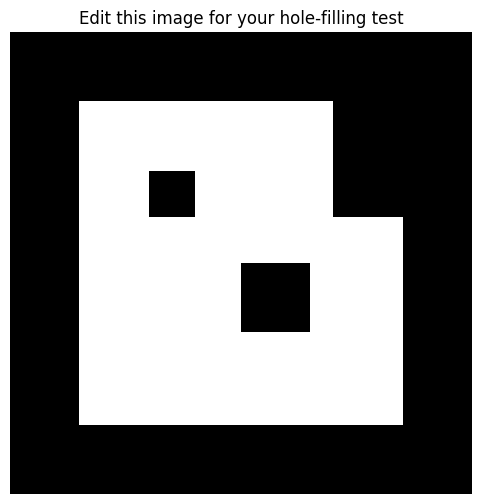

In [13]:
student_holes = np.zeros((20, 20), dtype=np.uint8)
student_holes[3:17, 3:17] = 1
student_holes[6:8, 6:8] = 0
student_holes[10:13, 10:13] = 0
student_holes[3:8, 14:17] = 0

show(student_holes, "Edit this image for your hole-filling test")
plt.show()

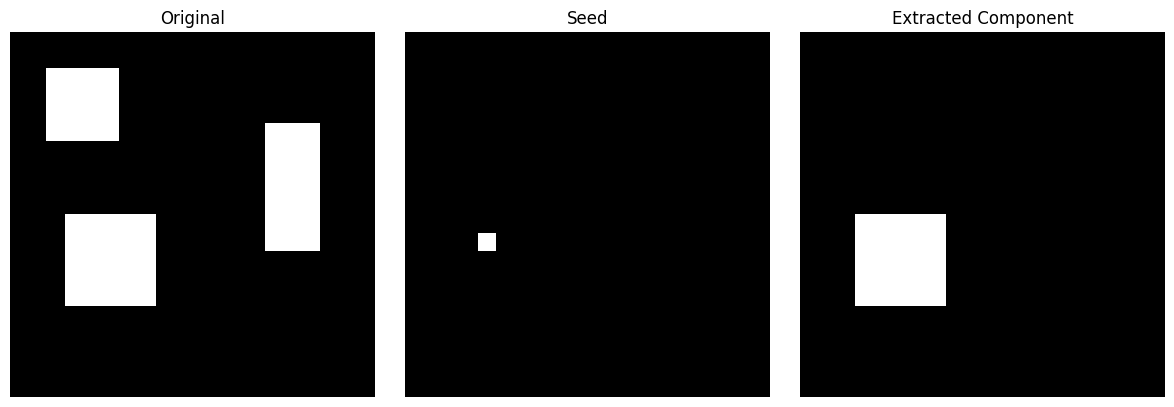

In [14]:
cc_img = np.zeros((20, 20), dtype=np.uint8)
cc_img[2:6, 2:6] = 1
cc_img[10:15, 3:8] = 1
cc_img[5:12, 14:17] = 1

seed_component = np.zeros_like(cc_img, dtype=bool)
seed_component[11, 4] = True

component = seed_component.copy()
while True:
    grown = ndimage.binary_dilation(component, structure=structure) & cc_img.astype(bool)
    if np.array_equal(grown, component):
        break
    component = grown

show_triplet(cc_img, seed_component.astype(np.uint8), component.astype(np.uint8),
             "Original", "Seed", "Extracted Component")
plt.show()

Number of connected components: 3
Labels present: [0 1 2 3]


/tmp/ipykernel_968/1376084510.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)


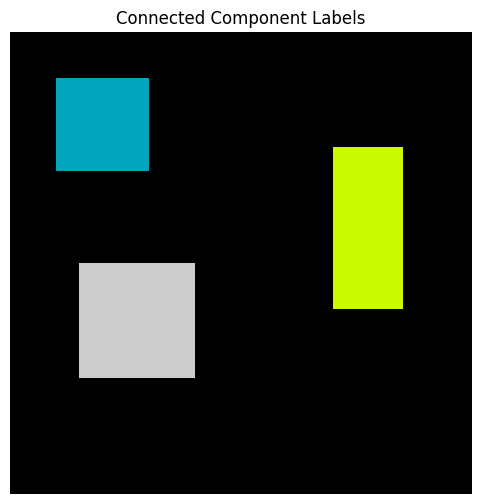

In [15]:
labeled, num_features = ndimage.label(cc_img)

print("Number of connected components:", num_features)
print("Labels present:", np.unique(labeled))

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)
ax.imshow(labeled, cmap=cmap)
ax.set_title("Connected Component Labels")
ax.axis("off")
plt.show()

Areas of components: [16. 21. 25.]


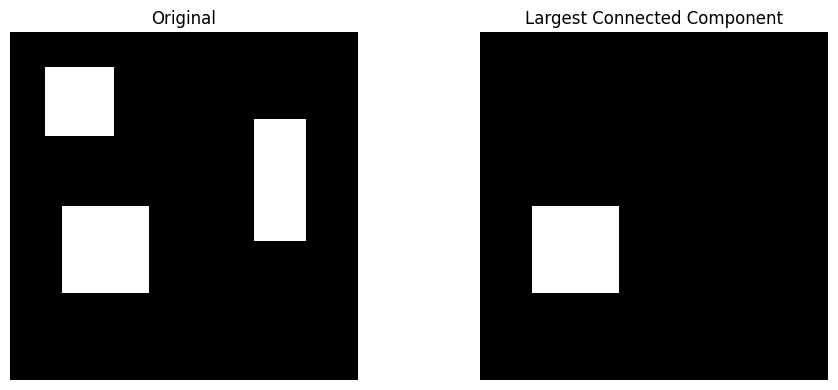

In [16]:
labeled_student, n_student = ndimage.label(cc_img)
areas = ndimage.sum(cc_img, labeled_student, index=range(1, n_student + 1))

print("Areas of components:", areas)

largest_label = np.argmax(areas) + 1
largest_component = (labeled_student == largest_label).astype(np.uint8)

show_pair(cc_img, largest_component, "Original", "Largest Connected Component")
plt.show()

Number of grains: 152


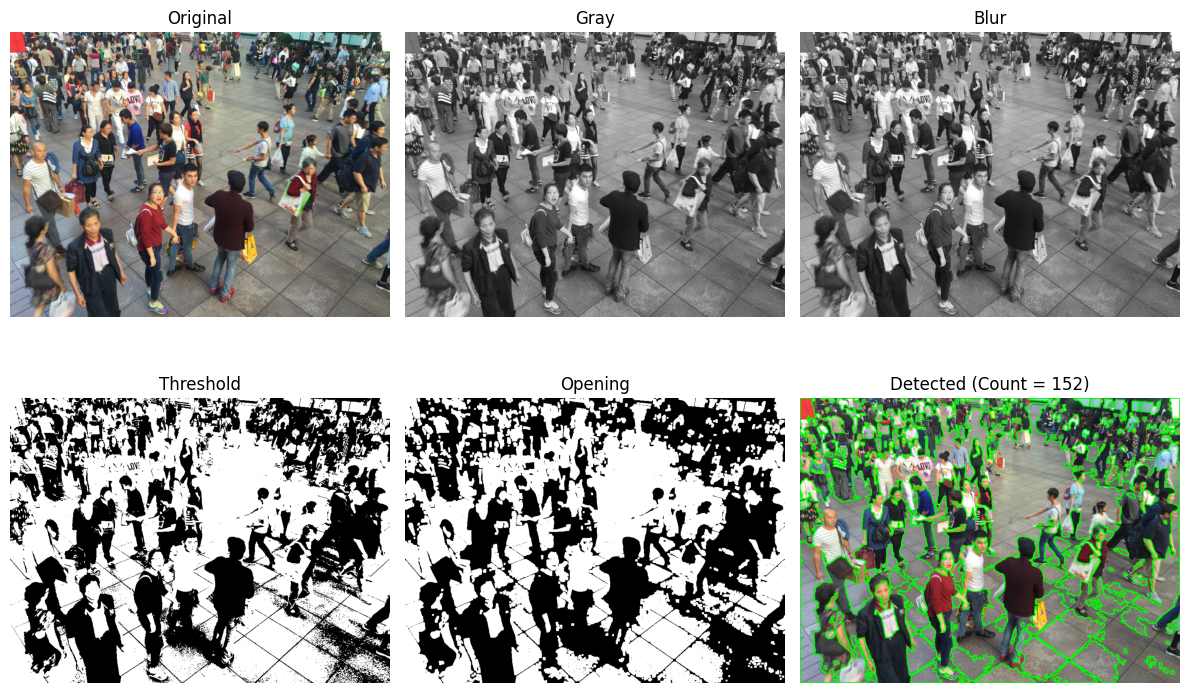

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("/content/drive/MyDrive/archive/ShanghaiTech/part_B/train_data/images/IMG_21.jpg")
original = img.copy()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (1, 1), 0)

_, thresh = cv2.threshold(blur, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

contours, _ = cv2.findContours(opening,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

count = 0
output = img_rgb.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 50:
        count += 1
        cv2.drawContours(output, [cnt], -1, (0, 255, 0), 2)

print("Number of grains:", count)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Gray")
plt.imshow(gray, cmap='gray')
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Blur")
plt.imshow(blur, cmap='gray')
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Threshold")
plt.imshow(thresh, cmap='gray')
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Opening")
plt.imshow(opening, cmap='gray')
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title(f"Detected (Count = {count})")
plt.imshow(output)
plt.axis("off")

plt.tight_layout()
plt.show()